In [174]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = \
    read_model_runs('../../data/processed/model-runs')


In [175]:
from read_model_runs import filter_complete_questions

models = ['gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it']
firacs = ['FILA_', 'FIR__', 'FI___', 'FIL__', '_____', 'unstructured']
question_long_df, question_wide_df, model_order, firac_order = filter_complete_questions(question_long_df, models, firacs)

print('shape:', question_long_df.shape)
print('# unique questions:', question_long_df['question_id'].nunique())
print("model order:", model_order)
print("firac order:", firac_order)


shape: (42210, 32)
# unique questions: 2345
model order: ['gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it']
firac order: ['_____', 'unstructured', 'FIL__', 'FI___', 'FIR__', 'FILA_']


In [176]:
question_wide_df.head()

,question_id,model_name,_____,unstructured,FIL__,FI___,FIR__,FILA_
0,oab-1.pdf-002,gemma-3-12b-it,False,True,True,True,True,True
1,oab-1.pdf-002,gemma-3-27b-it,False,True,True,True,True,True
2,oab-1.pdf-002,gemma-3-4b-it,True,True,True,True,True,True
3,oab-1.pdf-003,gemma-3-12b-it,False,False,False,False,True,True
4,oab-1.pdf-003,gemma-3-27b-it,False,False,True,True,True,True


In [177]:
question_wide_df.columns

Index(['question_id', 'model_name', '_____', 'unstructured', 'FIL__', 'FI___',
       'FIR__', 'FILA_'],
      dtype='object')

In [178]:
import pandas as pd

# -------------------------------
# 1. Definir colunas FIRAC
# -------------------------------
firac_cols = firac_order

# -------------------------------
# 2. Converter booleanos → int
#    (PCA não gosta de True/False)
# -------------------------------
question_wide_df[firac_cols] = (
    question_wide_df[firac_cols]
    .astype(int)
)

# -------------------------------
# 3. Long → Wide:
#    (question_id, model_name) × FIRAC
# -------------------------------
df_long = question_wide_df.melt(
    id_vars=["question_id", "model_name"],
    value_vars=firac_cols,
    var_name="firac",
    value_name="value"
)

# -------------------------------
# 4. Criar nome da coluna combinada
#    model_name + FIRAC
# -------------------------------
df_long["feature"] = (
    df_long["model_name"] + "|" + df_long["firac"]
)

# -------------------------------
# 5. Pivot final:
#    1 linha por question_id
# -------------------------------
pca_input_df = (
    df_long
    .pivot_table(
        index="question_id",
        columns="feature",
        values="value",
        aggfunc="mean"   # robusto caso haja duplicatas
    )
    .fillna(0)
)

# -------------------------------
# 6. (Opcional) Ordenar colunas
# -------------------------------
pca_input_df = pca_input_df.sort_index(axis=1)

# -------------------------------
# 7. Pronto para PCA
# -------------------------------
print(pca_input_df.shape)
pca_input_df.head()


(2345, 18)


feature,gemma-3-12b-it|FILA_,gemma-3-12b-it|FIL__,gemma-3-12b-it|FIR__,gemma-3-12b-it|FI___,gemma-3-12b-it|_____,gemma-3-12b-it|unstructured,gemma-3-27b-it|FILA_,gemma-3-27b-it|FIL__,gemma-3-27b-it|FIR__,gemma-3-27b-it|FI___,gemma-3-27b-it|_____,gemma-3-27b-it|unstructured,gemma-3-4b-it|FILA_,gemma-3-4b-it|FIL__,gemma-3-4b-it|FIR__,gemma-3-4b-it|FI___,gemma-3-4b-it|_____,gemma-3-4b-it|unstructured
question_id,,,,,,,,,,,,,,,,,,
oab-1.pdf-002,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
oab-1.pdf-003,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
oab-1.pdf-004,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
oab-1.pdf-005,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
oab-1.pdf-006,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0


In [179]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------
# 1. Matriz X (questions × features)
# ---------------------------------------
X = pca_input_df.values
question_ids = pca_input_df.index
feature_names = pca_input_df.columns

# ---------------------------------------
# 2. Padronização (Z-score)
#    Essencial para PCA interpretável
# ---------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------
# 3. PCA
#    (comece sem fixar n_components)
# ---------------------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# ---------------------------------------
# 4. Scores do PCA (por question_id)
# ---------------------------------------
pca_scores_df = pd.DataFrame(
    X_pca,
    index=question_ids,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

pca_scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
question_id,,,,,,,,,,,,,,,,,,
oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,0.030276,0.199831,-0.441069,-0.949218,0.052654,0.433758,0.574385,-0.386226,-1.032898,-0.345120,-1.531358,-0.273165,0.621459,0.251065
oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,-1.272295,0.803649,-0.176239,-0.010216,0.276380,0.438431,1.306208,0.940574,0.606896,-0.382623,-0.489931,0.062937,0.152470,0.134650
oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,-0.475456,0.334971,0.749236,0.137101,0.886844,1.103818,0.866351,-1.187548,-0.626724,0.405295,-0.473842,-1.100276,-0.154992,-0.065863
oab-1.pdf-005,0.113715,-6.675350,-0.199894,0.107841,0.749690,1.159966,-0.984933,-0.242319,2.557660,-3.328763,0.455791,1.493676,-1.840929,-0.016450,0.443545,0.451682,0.202169,0.226066
oab-1.pdf-006,2.132751,-0.111454,-0.839197,-0.192117,0.097045,-0.531424,1.519451,-0.270051,0.856657,1.140298,0.289010,0.325660,-0.011040,-0.072027,0.100733,-0.060244,0.040731,-0.069990


In [180]:

# ---------------------------------------
# 5. Variância explicada
# ---------------------------------------
explained_variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance_df

,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.342818,0.342818
1,PC2,0.101043,0.443861
2,PC3,0.088077,0.531938
3,PC4,0.058709,0.590648
4,PC5,0.054497,0.645145
5,PC6,0.043638,0.688784
6,PC7,0.041674,0.730458
7,PC8,0.036919,0.767377
8,PC9,0.031063,0.798440
9,PC10,0.030050,0.828490


In [181]:
# ---------------------------------------
# 6. Loadings
# ---------------------------------------
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# ---------------------------------------
# 6.1 Quebrar feature → model_name + firac
# ---------------------------------------
loadings_df = (
    loadings_df
    .reset_index()
    .rename(columns={"index": "feature"})
)

loadings_df[["model_name", "firac"]] = (
    loadings_df["feature"]
    .str.split("|", expand=True)
)

# Remove coluna feature
loadings_df = loadings_df.drop(columns="feature")

# ---------------------------------------
# 6.2 Reordenar colunas
# ---------------------------------------
pc_cols = [c for c in loadings_df.columns if c.startswith("PC")]

loadings_df = loadings_df[
    [ "firac", "model_name"] + pc_cols
].sort_values(by='firac')


loadings_df = (
    loadings_df
    .set_index(["firac", "model_name"])
)

loadings_df.head(100)


PC1       PC2       PC3       PC4       PC5  \
firac        model_name                                                         
FILA_        gemma-3-12b-it  0.107406  0.487496 -0.053008 -0.376647  0.191831   
             gemma-3-4b-it   0.128230  0.336638  0.240830 -0.083600 -0.028822   
             gemma-3-27b-it  0.091688  0.479272 -0.037303 -0.494116 -0.005438   
FIL__        gemma-3-12b-it  0.281300 -0.033142 -0.180557  0.026741  0.331992   
             gemma-3-4b-it   0.231902 -0.067256  0.418108  0.046194  0.002852   
             gemma-3-27b-it  0.290856 -0.050167 -0.202273 -0.057746 -0.307517   
FIR__        gemma-3-4b-it   0.197187  0.223200  0.238839  0.387247  0.028486   
             gemma-3-27b-it  0.185240  0.347505 -0.126998  0.360981 -0.276874   
             gemma-3-12b-it  0.190135  0.330170 -0.113333  0.514722  0.109091   
FI___        gemma-3-27b-it  0.291549 -0.062769 -0.193200 -0.094015 -0.324646   
             gemma-3-12b-it  0.289306 -0.081563 -0.161834 -0.011716  0.334979   
             gemma-3-4b-it   0.251031 -0.043888  0.379364  0.002522 -0.002017   
_____        gemma-3-4b-it   0.217508 -0.122200  0.387315 -0.093860 -0.073897   
             gemma-3-27b-it  0.279742 -0.124053 -0.182270 -0.083471 -0.317795   
             gemma-3-12b-it  0.277573 -0.161691 -0.152661 -0.029707  0.357230   
unstructured gemma-3-27b-it  0.280236 -0.136930 -0.168011 -0.093638 -0.301224   
             gemma-3-12b-it  0.268877 -0.164616 -0.125269 -0.017897  0.354399   
             gemma-3-4b-it   0.227173 -0.129457  0.381522 -0.144493 -0.012775   

                                  PC6       PC7       PC8       PC9      PC10  \
firac        model_name                                                         
FILA_        gemma-3-12b-it -0.149322 -0.147537  0.082265  0.464183 -0.400078   
             gemma-3-4b-it   0.544848  0.636474 -0.135807 -0.181823 -0.159410   
             gemma-3-27b-it -0.133272 -0.129582  0.109451 -0.351026  0.404053   
FIL__        gemma-3-12b-it  0.227543 -0.097537 -0.327916  0.118249  0.204100   
             gemma-3-4b-it   0.103822 -0.378082  0.126721 -0.282341 -0.197204   
             gemma-3-27b-it  0.210045 -0.152110 -0.118650  0.036974  0.023630   
FIR__        gemma-3-4b-it   0.211688 -0.027764  0.535920  0.301951  0.453005   
             gemma-3-27b-it -0.316371 -0.062218 -0.258957 -0.376256  0.066516   
             gemma-3-12b-it -0.232850  0.080806 -0.097397  0.143680 -0.236840   
FI___        gemma-3-27b-it  0.207977 -0.159268 -0.081880  0.065197  0.079042   
             gemma-3-12b-it  0.197485 -0.140903 -0.268544  0.094456  0.132269   
             gemma-3-4b-it   0.082714 -0.334236  0.003909 -0.145789 -0.369791   
_____        gemma-3-4b-it  -0.302050  0.242428 -0.385306  0.210396  0.067989   
             gemma-3-27b-it -0.048505  0.123220  0.278542  0.195232 -0.159364   
             gemma-3-12b-it -0.127983  0.139788  0.182480 -0.224710 -0.049715   
unstructured gemma-3-27b-it -0.102695  0.233257  0.207173  0.001500 -0.091820   
             gemma-3-12b-it -0.173930  0.228614  0.271403 -0.287751 -0.070948   
             gemma-3-4b-it  -0.342674  0.111678 -0.081405  0.172325  0.313030   

                                 PC11      PC12      PC13      PC14      PC15  \
firac        model_name                                                         
FILA_        gemma-3-12b-it  0.200745  0.126732 -0.261122  0.025155  0.108089   
             gemma-3-4b-it   0.098287 -0.058026  0.021544  0.041235  0.096981   
             gemma-3-27b-it -0.273395 -0.085596  0.242587 -0.115232 -0.159096   
FIL__        gemma-3-12b-it -0.205889 -0.180648 -0.270922  0.052114 -0.052346   
             gemma-3-4b-it   0.025494 -0.165724 -0.201484 -0.561865  0.290673   
             gemma-3-27b-it  0.339493  0.202045  0.073027 -0.183835 -0.279946   
FIR__        gemma-3-4b-it  -0.051240  0.211483 -0.101640  0.068946 -0.037694   
             gemma-3-27b-it  0.073839  0.143036 -0.342263  0.28

In [182]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 0) Renomear nível do MultiIndex: model_name -> model
# --------------------------------------------------
if isinstance(loadings_df.index, pd.MultiIndex):
    loadings_df = loadings_df.rename_axis(
        index={"model_name": "model"}
    )


def escape_latex(text):
    if not isinstance(text, str):
        return text
    return (
        text
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
        .replace("&", "\\&")
        .replace("#", "\\#")
        .replace("{", "\\{")
        .replace("}", "\\}")
    )


# --------------------------------------------------
# 1) Selecionar PC1, PC2 e PC3
# --------------------------------------------------
latex_df = loadings_df[["PC1", "PC2", "PC3"]].copy()
latex_df = latex_df.round(2)


# --------------------------------------------------
# 2) Escape LaTeX nos nomes das features (index)
# --------------------------------------------------
latex_df.index = latex_df.index.map(escape_latex)


# --------------------------------------------------
# 3) Função de coloração ACL-style
# --------------------------------------------------
def color_cell(val, eps=0.05):
    if pd.isna(val):
        return ""

    if abs(val) < eps:
        return f"{val:.2f}"

    intensity = int(min(abs(val) * 100, 70))

    if val > 0:
        return f"\\cellcolor{{green!{intensity}}}{val:.2f}"
    else:
        return f"\\cellcolor{{red!{intensity}}}{val:.2f}"


# --------------------------------------------------
# 4) Aplicar coloração
# --------------------------------------------------
styled_df = latex_df.copy()
for col in styled_df.columns:
    styled_df[col] = styled_df[col].apply(color_cell)


# --------------------------------------------------
# 5) Gerar LaTeX
# --------------------------------------------------
latex_table = styled_df.to_latex(
    escape=False,   # NÃO mudar isso
    column_format="lccc",
    bold_rows=False,
    caption=(
        "PCA loadings for the first three principal components. "
        "Green indicates positive contributions, red negative contributions, "
        "and near-zero values are shown in white."
    ),
    label="tab:pca_loadings_pc1_pc3"
)

print(latex_table)


\begin{table}
\caption{PCA loadings for the first three principal components. Green indicates positive contributions, red negative contributions, and near-zero values are shown in white.}
\label{tab:pca_loadings_pc1_pc3}
\begin{tabular}{lccc}
\toprule
 &  & PC1 & PC2 & PC3 \\
firac & model &  &  &  \\
\midrule
\multirow[t]{3}{*}{FILA_} & gemma-3-12b-it & \cellcolor{green!11}0.11 & \cellcolor{green!49}0.49 & \cellcolor{red!5}-0.05 \\
 & gemma-3-4b-it & \cellcolor{green!13}0.13 & \cellcolor{green!34}0.34 & \cellcolor{green!24}0.24 \\
 & gemma-3-27b-it & \cellcolor{green!9}0.09 & \cellcolor{green!48}0.48 & -0.04 \\
\cline{1-5}
\multirow[t]{3}{*}{FIL__} & gemma-3-12b-it & \cellcolor{green!28}0.28 & -0.03 & \cellcolor{red!18}-0.18 \\
 & gemma-3-4b-it & \cellcolor{green!23}0.23 & \cellcolor{red!7}-0.07 & \cellcolor{green!42}0.42 \\
 & gemma-3-27b-it & \cellcolor{green!28}0.29 & \cellcolor{red!5}-0.05 & \cellcolor{red!20}-0.20 \\
\cline{1-5}
\multirow[t]{3}{*}{FIR__} & gemma-3-4b-it & \cellco

In [183]:
import pandas as pd

question_meta_df = (
    question_long_df[
        ["question_id", "materia", "tema", "oab_test_id"]
    ]
    .drop_duplicates(subset=["question_id"])
)

pca_scores_df = (
    pca_scores_df
    .merge(
        question_meta_df,
        on="question_id",
        how="left"
    )
)


# Reordena as colunas: novas colunas primeiro
cols = ["materia", "tema", "oab_test_id"] + [
    c for c in pca_scores_df.columns 
    if c not in ["materia", "tema", "oab_test_id"]
]

pca_scores_df = pca_scores_df[cols]

pca_scores_df.to_csv("../../data/processed/pca.csv")

pca_scores_df

,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,PC5,PC6,...,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,ÉTICA PROFISSIONAL,DIREITOS DO ADVOGADO,XV,oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,0.030276,0.199831,...,0.052654,0.433758,0.574385,-0.386226,-1.032898,-0.345120,-1.531358,-0.273165,0.621459,0.251065
1,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XV,oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,-1.272295,0.803649,...,0.276380,0.438431,1.306208,0.940574,0.606896,-0.382623,-0.489931,0.062937,0.152470,0.134650
2,ÉTICA PROFISSIONAL,SOCIEDADE DE ADVOGADOS,XV,oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,-0.475456,0.334971,...,0.886844,1.103818,0.866351,-1.187548,-0.626724,0.405295,-0.473842,-1.100276,-0.154992,-0.065863
3,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XIV,oab-1.pdf-005,0.113715,-6.675350,-0.199894,0.107841,0.749690,1.159966,...,2.557660,-3.328763,0.455791,1.493676,-1.840929,-0.016450,0.443545,0.451682,0.202169,0.226066
4,ÉTICA PROFISSIONAL,ÉTICA DO ADVOGADO,XIV,oab-1.pdf-006,2.132751,-0.111454,-0.839197,-0.192117,0.097045,-0.531424,...,0.856657,1.140298,0.289010,0.325660,-0.011040,-0.072027,0.100733,-0.060244,0.040731,-0.069990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2340,DIREITO TRIBUTÁRIO,RESPONSABILIDADE TRIBUTÁRIA,II,oab-99.pdf-007,0.597806,0.057562,-0.802045,-0.945117,-1.401293,-0.386443,...,1.228538,0.390492,-0.173324,-1.039059,0.023074,-0.233811,0.179945,-0.337811,-0.026241,-0.116146
2341,DIREITO TRIBUTÁRIO,LEGISLAÇÃO TRIBUTÁRIA,II,oab-99.pdf-008,-2.234527,1.865581,-0.336332,0.894707,0.072600,0.828444,...,0.443124,0.811896,0.155020,0.134776,-0.111358,0.117447,-0.001918,0.199217,-0.504764,1.927414
2342,DIREITO TRIBUTÁRIO,RESPONSABILIDADE TRIBUTÁRIA,II,oab-99.pdf-009,-2.134829,-3.417972,2.845127,2.512538,2.261280,0.060963,...,2.996674,-2.837023,2.039128,1.262311,0.256987,0.992853,-0.407379,0.619138,0.151591,0.275467
2343,DIREITO TRIBUTÁRIO,CRÉDITO TRIBUTÁRIO,II,oab-99.pdf-010,3.098946,-0.333835,0.756338,-0.094621,0.098718,-0.158205,...,0.000003,0.006022,-0.031037,0.034511,-0.017543,-0.054748,0.026696,-0.012033,-0.045433,0.004108


In [184]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 0) Renomear coluna model_name -> model (se existir)
# --------------------------------------------------
if "model_name" in loadings_df.columns:
    loadings_df = loadings_df.rename(columns={"model_name": "model"})


def escape_latex(text):
    if not isinstance(text, str):
        return text
    return (
        text
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
        .replace("&", "\\&")
        .replace("#", "\\#")
        .replace("{", "\\{")
        .replace("}", "\\}")
    )


# --------------------------------------------------
# 1) Selecionar PC1, PC2 e PC3
# --------------------------------------------------
latex_df = loadings_df[["PC1", "PC2", "PC3"]].copy()
latex_df = latex_df.round(2)


# --------------------------------------------------
# 2) Escape LaTeX nos nomes das features (index)
# --------------------------------------------------
latex_df.index = latex_df.index.map(escape_latex)


# --------------------------------------------------
# 3) Função de coloração ACL-style
# --------------------------------------------------
def color_cell(val, eps=0.05):
    if pd.isna(val):
        return ""

    if abs(val) < eps:
        return f"{val:.2f}"

    intensity = int(min(abs(val) * 100, 70))

    if val > 0:
        return f"\\cellcolor{{green!{intensity}}}{val:.2f}"
    else:
        return f"\\cellcolor{{red!{intensity}}}{val:.2f}"


# --------------------------------------------------
# 4) Aplicar coloração
# --------------------------------------------------
styled_df = latex_df.copy()
for col in styled_df.columns:
    styled_df[col] = styled_df[col].apply(color_cell)


# --------------------------------------------------
# 5) Gerar LaTeX
# --------------------------------------------------
latex_table = styled_df.to_latex(
    escape=False,   # NÃO mudar isso
    column_format="lccc",
    bold_rows=False,
    caption=(
        "PCA loadings for the first three principal components. "
        "Green indicates positive contributions, red negative contributions, "
        "and near-zero values are shown in white."
    ),
    label="tab:pca_loadings_pc1_pc3"
)

print(latex_table)


\begin{table}
\caption{PCA loadings for the first three principal components. Green indicates positive contributions, red negative contributions, and near-zero values are shown in white.}
\label{tab:pca_loadings_pc1_pc3}
\begin{tabular}{lccc}
\toprule
 &  & PC1 & PC2 & PC3 \\
firac & model &  &  &  \\
\midrule
\multirow[t]{3}{*}{FILA_} & gemma-3-12b-it & \cellcolor{green!11}0.11 & \cellcolor{green!49}0.49 & \cellcolor{red!5}-0.05 \\
 & gemma-3-4b-it & \cellcolor{green!13}0.13 & \cellcolor{green!34}0.34 & \cellcolor{green!24}0.24 \\
 & gemma-3-27b-it & \cellcolor{green!9}0.09 & \cellcolor{green!48}0.48 & -0.04 \\
\cline{1-5}
\multirow[t]{3}{*}{FIL__} & gemma-3-12b-it & \cellcolor{green!28}0.28 & -0.03 & \cellcolor{red!18}-0.18 \\
 & gemma-3-4b-it & \cellcolor{green!23}0.23 & \cellcolor{red!7}-0.07 & \cellcolor{green!42}0.42 \\
 & gemma-3-27b-it & \cellcolor{green!28}0.29 & \cellcolor{red!5}-0.05 & \cellcolor{red!20}-0.20 \\
\cline{1-5}
\multirow[t]{3}{*}{FIR__} & gemma-3-4b-it & \cellco

In [185]:
pip install adjustText


Note: you may need to restart the kernel to use updated packages.


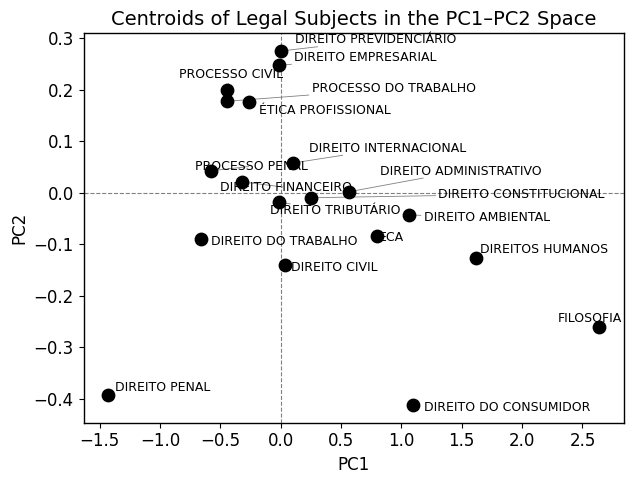

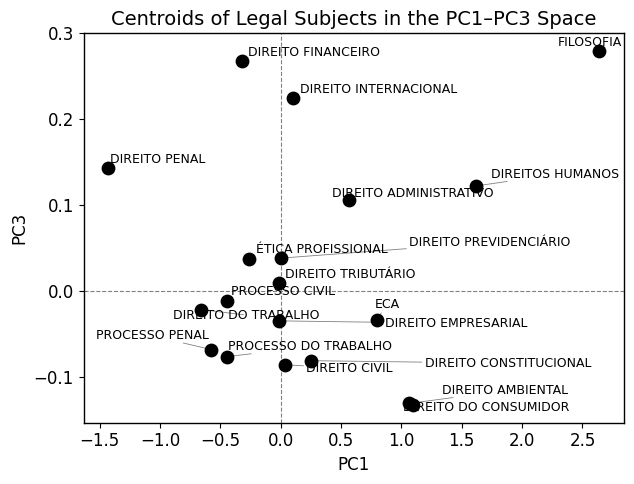

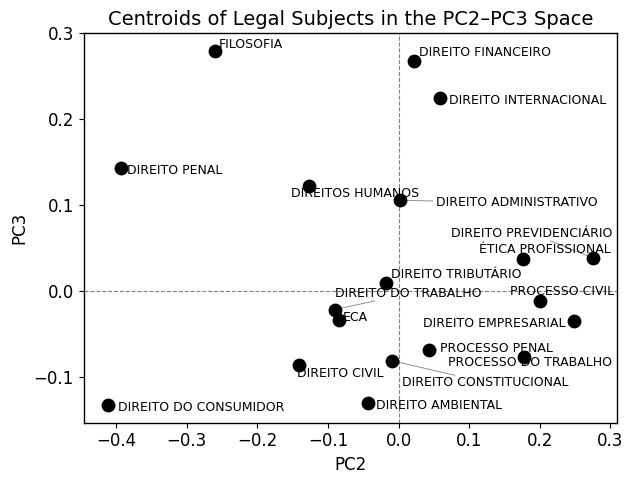

In [186]:
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
from itertools import combinations

# --------------------------------------------------
# 0. Filtra matéria a ser removida
# --------------------------------------------------
filtered_df = pca_scores_df[
    pca_scores_df["materia"] != "DIREITO ELEITORAL"
]

# --------------------------------------------------
# 1. Define pares de PCs
# --------------------------------------------------
pc_pairs = list(combinations(["PC1", "PC2", "PC3"], 2))

# --------------------------------------------------
# 2. Loop sobre os pares de PCs
# --------------------------------------------------
for pc_x, pc_y in pc_pairs:

    # ----------------------------------------------
    # 2.1 Calcula centróides por matéria
    # ----------------------------------------------
    centroids_df = (
        filtered_df
        .groupby("materia")[[pc_x, pc_y]]
        .mean()
        .reset_index()
    )

    # ----------------------------------------------
    # 2.2 Plot ACL-style
    # ----------------------------------------------
    plt.figure(figsize=(6.5, 5))

    plt.scatter(
        centroids_df[pc_x],
        centroids_df[pc_y],
        s=80,
        color="black",
        zorder=3
    )

    # Labels com repulsão
    texts = []
    for _, row in centroids_df.iterrows():
        texts.append(
            plt.text(
                row[pc_x],
                row[pc_y],
                row["materia"],
                fontsize=9
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.6
        )
    )

    # Linhas de referência
    plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)
    plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", zorder=1)

    # Labels e título
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(f"Centroids of Legal Subjects in the {pc_x}–{pc_y} Space")

    # ----------------------------------------------
    # 2.3 Salva em PDF e mostra na tela
    # ----------------------------------------------
    plt.tight_layout()
    plt.savefig(
        f"../../reports/pca_centroids_{pc_x.lower()}_{pc_y.lower()}_materia.pdf",
        format="pdf",
        bbox_inches="tight"
    )
    plt.show()


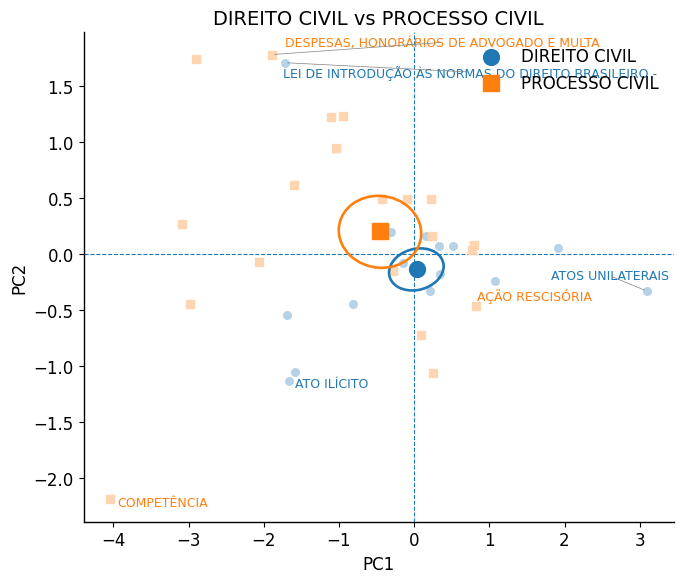

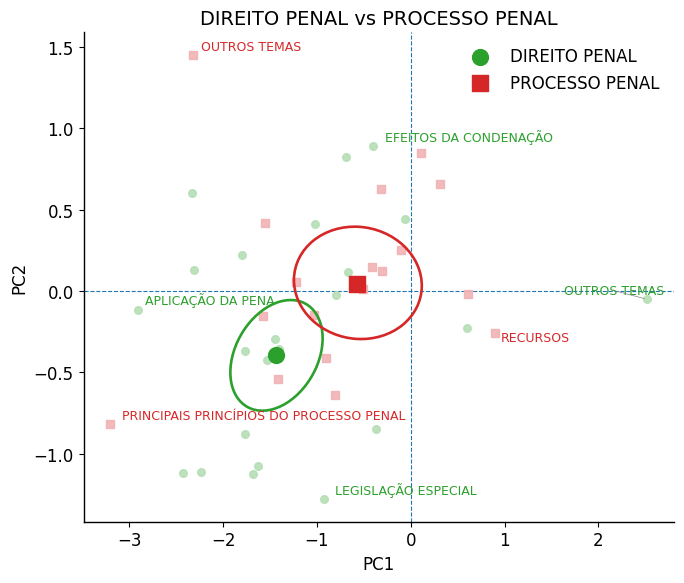

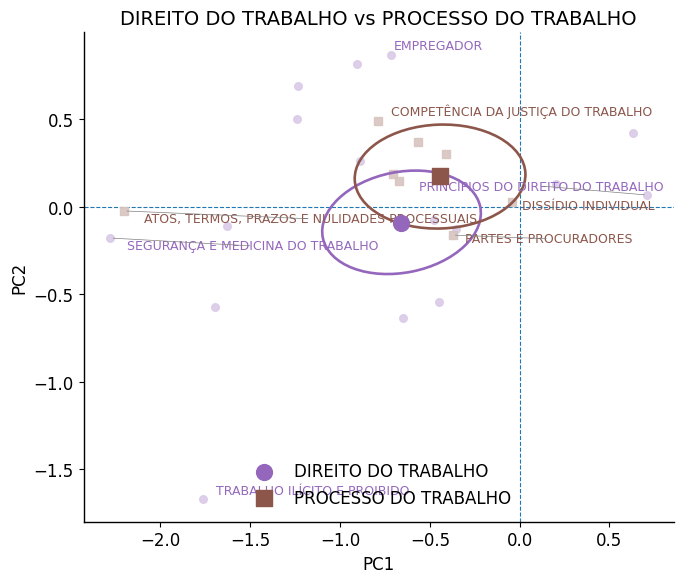

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors
from adjustText import adjust_text

# -----------------------------
# CONFIGURAÇÕES
# -----------------------------
BOOTSTRAP_N = 1000
CONF_LEVEL = 0.95

pairs = [
    ("DIREITO CIVIL", "PROCESSO CIVIL"),
    ("DIREITO PENAL", "PROCESSO PENAL"),
    ("DIREITO DO TRABALHO", "PROCESSO DO TRABALHO"),
]

materia_colors = {
    "DIREITO CIVIL": "#1f77b4",
    "PROCESSO CIVIL": "#ff7f0e",
    "DIREITO PENAL": "#2ca02c",
    "PROCESSO PENAL": "#d62728",
    "DIREITO DO TRABALHO": "#9467bd",
    "PROCESSO DO TRABALHO": "#8c564b",
}

materia_markers = {
    "A": "o",
    "B": "s",
}

# Estilo ACL
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.figsize": (7, 6),
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})


# -----------------------------
# FUNÇÕES AUXILIARES
# -----------------------------
def lighten_color(color, amount=0.6):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)


def bootstrap_centroids(df, n_bootstrap=1000):
    data = df[["PC1", "PC2"]].values
    n = len(data)

    centroids = []
    for _ in range(n_bootstrap):
        sample = data[np.random.choice(n, size=n, replace=True)]
        centroids.append(sample.mean(axis=0))

    return np.array(centroids)


def plot_confidence_ellipse(points, ax, confidence=0.95, color="black", **kwargs):
    cov = np.cov(points.T)
    mean = points.mean(axis=0)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    chi2_val = np.sqrt(
        np.quantile(
            np.random.chisquare(df=2, size=100000),
            confidence
        )
    )

    width, height = 2 * chi2_val * np.sqrt(eigvals)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        **kwargs
    )
    ax.add_patch(ellipse)


def get_axis_extreme_themes(df):
    extremes = pd.concat([
        df.loc[[df["PC1"].idxmax()]],
        df.loc[[df["PC1"].idxmin()]],
        df.loc[[df["PC2"].idxmax()]],
        df.loc[[df["PC2"].idxmin()]],
    ])

    # Remove duplicatas (caso um tema seja extremo em mais de um eixo)
    return extremes.drop_duplicates(subset="tema")


# -----------------------------
# PRÉ-CÁLCULOS
# -----------------------------
tema_centroids = (
    pca_scores_df
    .groupby(["materia", "tema"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
)


# -----------------------------
# LOOP PRINCIPAL
# -----------------------------
for mat_a, mat_b in pairs:

    fig, ax = plt.subplots()
    texts = []

    pair_info = [
        (mat_a, materia_markers["A"]),
        (mat_b, materia_markers["B"]),
    ]

    # -----------------------------
    # Temas (light + marker herdado)
    # -----------------------------
    for materia, marker in pair_info:

        base_color = materia_colors.get(materia, "black")
        light_color = lighten_color(base_color, amount=0.65)

        temas_df = tema_centroids[tema_centroids["materia"] == materia]

        ax.scatter(
            temas_df["PC1"],
            temas_df["PC2"],
            color=light_color,
            marker=marker,
            s=30,
            alpha=0.9,
            zorder=1
        )

        # -----------------------------
        # Temas extremos por eixo
        # -----------------------------
        extreme_df = get_axis_extreme_themes(temas_df)

        for _, row in extreme_df.iterrows():
            texts.append(
                ax.text(
                    row["PC1"],
                    row["PC2"],
                    row["tema"],
                    fontsize=9,
                    color=base_color
                )
            )

    # -----------------------------
    # Centróide + elipse
    # -----------------------------
    for materia, marker in pair_info:

        df_m = pca_scores_df[pca_scores_df["materia"] == materia]
        color = materia_colors.get(materia, "black")

        centroid = df_m[["PC1", "PC2"]].mean().values
        boot_centroids = bootstrap_centroids(df_m, BOOTSTRAP_N)

        ax.scatter(
            centroid[0],
            centroid[1],
            marker=marker,
            s=130,
            color=color,
            label=materia,
            zorder=4
        )

        plot_confidence_ellipse(
            boot_centroids,
            ax,
            confidence=CONF_LEVEL,
            color=color,
            linewidth=1.9
        )

    # -----------------------------
    # Ajuste automático dos labels
    # -----------------------------
    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.2, 1.2),
        expand_text=(1.2, 1.2),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.5
        )
    )

    # -----------------------------
    # Estilo ACL
    # -----------------------------
    ax.axhline(0, linewidth=0.8, linestyle="--", zorder=0)
    ax.axvline(0, linewidth=0.8, linestyle="--", zorder=0)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    ax.set_title(f"{mat_a} vs {mat_b}")

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # -----------------------------
    # SALVAR PDF
    # -----------------------------
    filename = f"../../reports/pca_themes_{mat_a.lower().replace(' ', '_')}_vs_{mat_b.lower().replace(' ', '_')}.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")

    plt.show()


In [188]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1) Classificação das questões por quadrante (PC1 x PC2)
# --------------------------------------------------
conditions = [
    (pca_scores_df["PC1"] <= 0) & (pca_scores_df["PC2"] < 0),
    (pca_scores_df["PC1"] <= 0) & (pca_scores_df["PC2"] > 0),
    (pca_scores_df["PC1"] > 0) & (pca_scores_df["PC2"] <= 0),
    (pca_scores_df["PC1"] > 0) & (pca_scores_df["PC2"] >= 0),
]

choices = [
    "hard_material",
    "hard_processual",
    "easy_material",
    "easy_processual",
]

pca_scores_df["question_type"] = np.select(
    conditions,
    choices,
    default="on_axis"  # cobre casos PC1 == 0 ou PC2 == 0
)

# --------------------------------------------------
# 2) Contagem de questões por quadrante
# --------------------------------------------------
quadrant_counts_df = (
    pca_scores_df
    .groupby("question_type")
    .size()
    .reset_index(name="n_questions")
)

# --------------------------------------------------
# 3) (Opcional) Ordenação semântica dos quadrantes
# --------------------------------------------------
question_type_order = [
    "easy_material",
    "easy_processual",
    "hard_material",
    "hard_processual",
    "on_axis",
]

quadrant_counts_df["question_type"] = pd.Categorical(
    quadrant_counts_df["question_type"],
    categories=question_type_order,
    ordered=True
)

quadrant_counts_df = quadrant_counts_df.sort_values("question_type")

# --------------------------------------------------
# 4) Exibição
# --------------------------------------------------
print(quadrant_counts_df)


     question_type  n_questions
0    easy_material          789
1  easy_processual          496
2    hard_material          361
3  hard_processual          699


In [189]:
import pandas as pd

question_stats_df = pd.read_csv("../../data/processed/question_level_stats.csv")
question_avg_consistency_stats_df = pd.read_csv("../../data/processed/question_avg_consistency.csv")
delta_firac_wide_df = pd.read_csv("../../data/processed/delta_firac.csv")

pca_scores_df = pca_scores_df.copy()
question_stats_df = question_stats_df.copy()

pca_scores_with_stats_df = (
    pca_scores_df
    .merge(
        question_stats_df,
        on="question_id",
        how="left"
    )
)

pca_scores_with_stats_df = (
    pca_scores_with_stats_df
    .merge(
        question_avg_consistency_stats_df,
        on="question_id",
        how="left"
    )
)

pca_scores_with_stats_df = (
    pca_scores_with_stats_df
    .merge(
        delta_firac_wide_df,
        on="question_id",
        how="left"
    )
)



pca_scores_with_stats_df 


,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,PC5,PC6,...,rule_source_count,Unnamed: 0,avg_consistency,n_models,FILA_,FIL__,FIR__,FI___,_____,unstructured
0,ÉTICA PROFISSIONAL,DIREITOS DO ADVOGADO,XV,oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,0.030276,0.199831,...,2,0,1.000000,3,0.133333,0.133333,0.133333,0.133333,-0.666667,0.133333
1,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XV,oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,-1.272295,0.803649,...,2,1,1.000000,3,0.666667,-0.133333,0.666667,-0.133333,-0.533333,-0.533333
2,ÉTICA PROFISSIONAL,SOCIEDADE DE ADVOGADOS,XV,oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,-0.475456,0.334971,...,1,2,0.666667,3,0.266667,-0.133333,0.266667,-0.133333,-0.533333,0.266667
3,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XIV,oab-1.pdf-005,0.113715,-6.675350,-0.199894,0.107841,0.749690,1.159966,...,1,3,0.000000,3,-0.400000,0.400000,-0.800000,0.400000,0.400000,0.000000
4,ÉTICA PROFISSIONAL,ÉTICA DO ADVOGADO,XIV,oab-1.pdf-006,2.132751,-0.111454,-0.839197,-0.192117,0.097045,-0.531424,...,1,4,0.666667,3,0.133333,-0.266667,0.133333,-0.266667,0.133333,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2340,DIREITO TRIBUTÁRIO,RESPONSABILIDADE TRIBUTÁRIA,II,oab-99.pdf-007,0.597806,0.057562,-0.802045,-0.945117,-1.401293,-0.386443,...,1,2340,0.666667,3,0.333333,-0.066667,-0.066667,-0.066667,-0.066667,-0.066667
2341,DIREITO TRIBUTÁRIO,LEGISLAÇÃO TRIBUTÁRIA,II,oab-99.pdf-008,-2.234527,1.865581,-0.336332,0.894707,0.072600,0.828444,...,2,2341,0.666667,3,0.666667,-0.133333,0.666667,-0.133333,-0.533333,-0.533333
2342,DIREITO TRIBUTÁRIO,RESPONSABILIDADE TRIBUTÁRIA,II,oab-99.pdf-009,-2.134829,-3.417972,2.845127,2.512538,2.261280,0.060963,...,1,2342,0.333333,3,0.200000,-0.600000,0.200000,-0.200000,0.200000,0.200000
2343,DIREITO TRIBUTÁRIO,CRÉDITO TRIBUTÁRIO,II,oab-99.pdf-010,3.098946,-0.333835,0.756338,-0.094621,0.098718,-0.158205,...,1,2343,1.000000,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


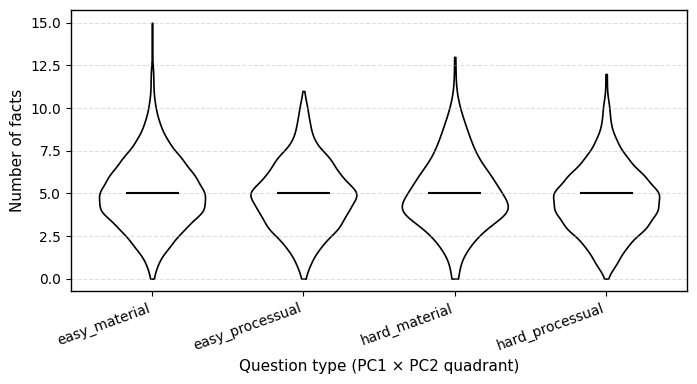

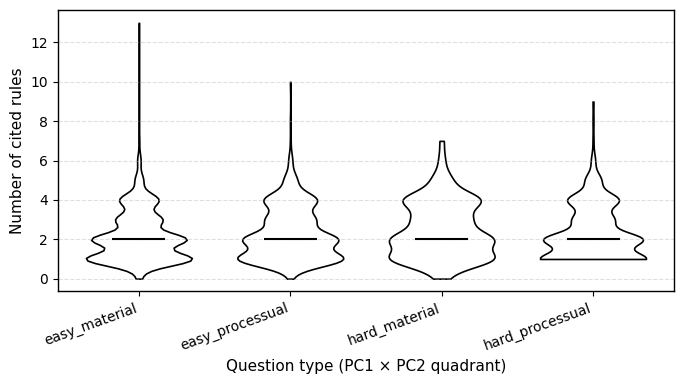

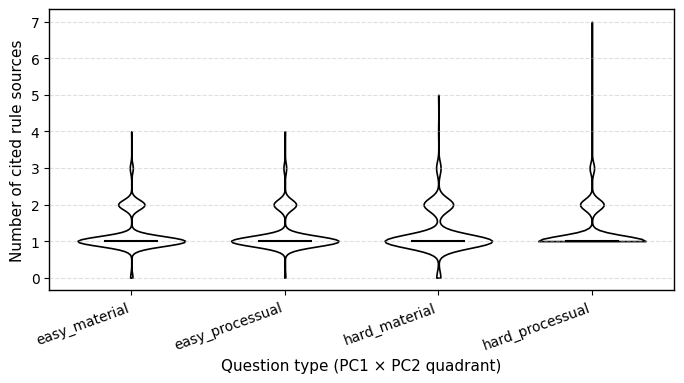

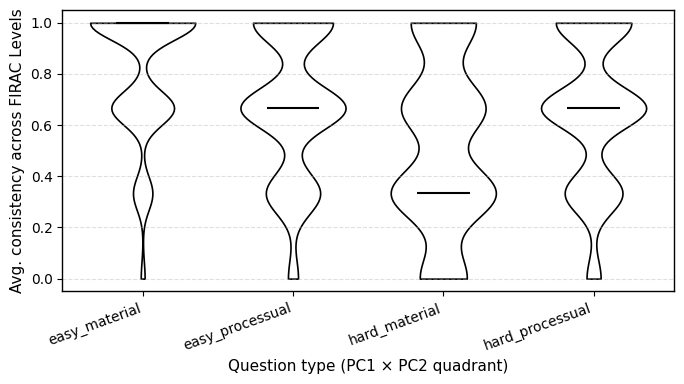

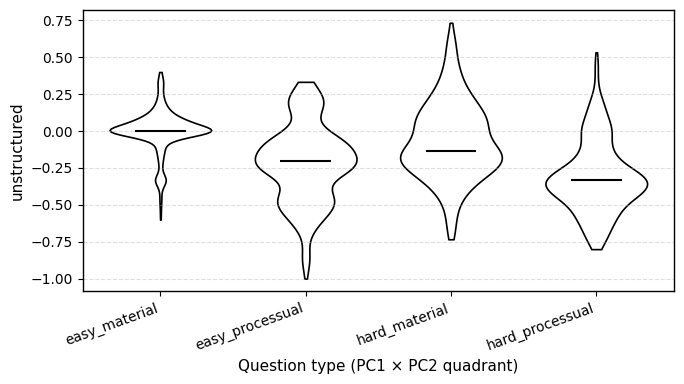

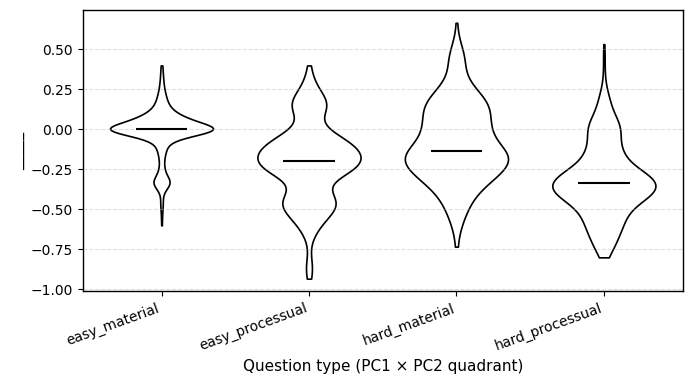

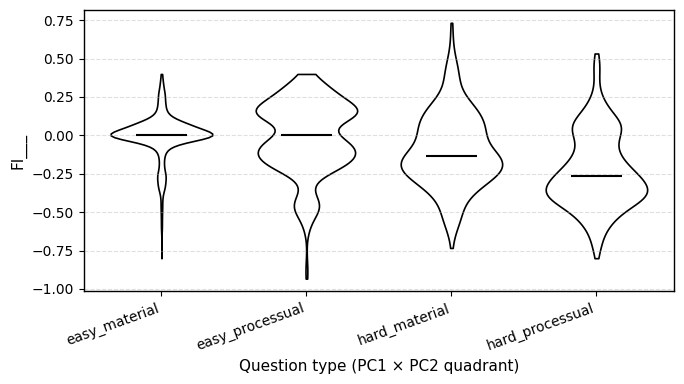

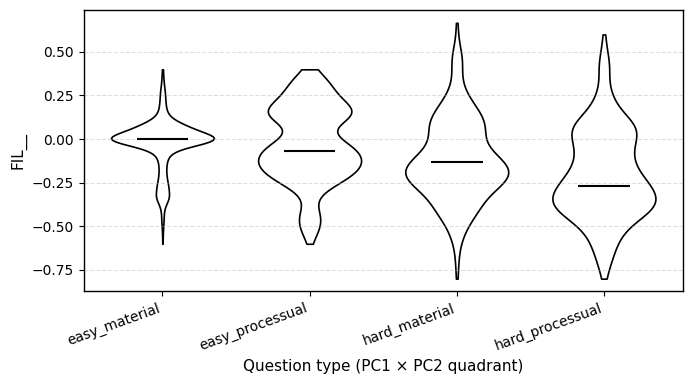

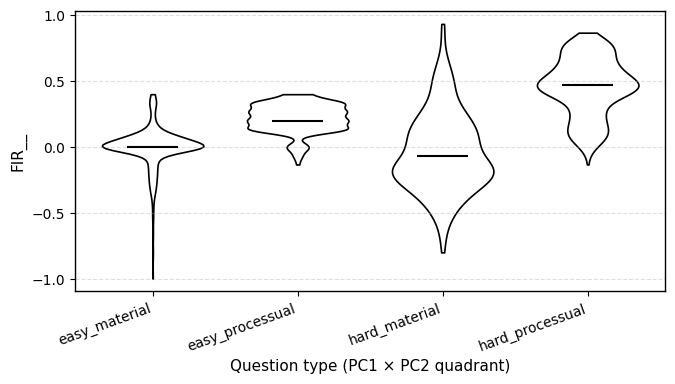

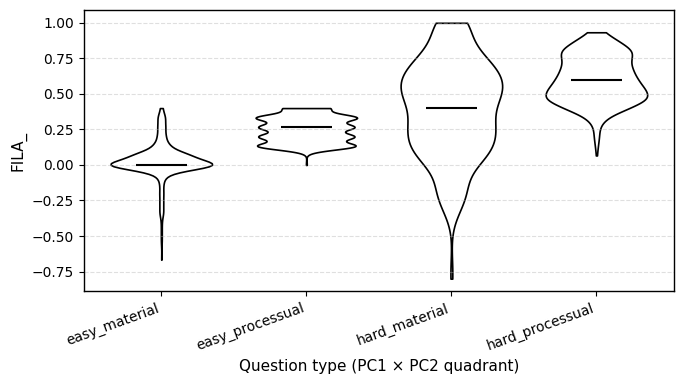

In [190]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1) Ordem semântica dos quadrantes
# --------------------------------------------------
question_type_order = [
    "easy_material",
    "easy_processual",
    "hard_material",
    "hard_processual",
]

# --------------------------------------------------
# 2) DataFrame base
# --------------------------------------------------
plot_df = (
    pca_scores_with_stats_df
    .query("question_type in @question_type_order")
    .assign(
        question_type=lambda df: pd.Categorical(
            df["question_type"],
            categories=question_type_order,
            ordered=True
        )
    )
)

# --------------------------------------------------
# 3) Métricas a analisar
# --------------------------------------------------
metrics = {
    "fact_count": "Number of facts",
    "rule_count": "Number of cited rules",
    "rule_source_count": "Number of cited rule sources",
    "avg_consistency": "Avg. consistency across FIRAC Levels",
    
    "unstructured": "unstructured",
    "_____": "_____",
    "FI___": "FI___",
    "FIL__": "FIL__",
    "FIR__": "FIR__",
    "FILA_": "FILA_",
}

# --------------------------------------------------
# 4) Loop: violin plot (1 violino por question_type)
# --------------------------------------------------
for metric, ylabel in metrics.items():

    data = [
        plot_df.loc[plot_df["question_type"] == qt, metric].dropna().values
        for qt in question_type_order
    ]

    plt.figure(figsize=(7, 4))

    vp = plt.violinplot(
        data,
        positions=np.arange(1, len(question_type_order) + 1),
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # --------------------------------------------------
    # Estilo ACL
    # --------------------------------------------------
    for body in vp["bodies"]:
        body.set_facecolor("white")
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(1.0)

    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(1.5)

    # --------------------------------------------------
    # Eixos
    # --------------------------------------------------
    plt.xticks(
        ticks=np.arange(1, len(question_type_order) + 1),
        labels=question_type_order,
        rotation=20,
        ha="right",
        fontsize=10
    )

    plt.ylabel(ylabel, fontsize=11)
    plt.xlabel("Question type (PC1 × PC2 quadrant)", fontsize=11)
    plt.yticks(fontsize=10)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
